# MHC class I epitope similarity

Question: **are epitopes more similar when they share an HLA allele, or when they come from the same source organism?**

Input: `iedb_human_pathogen_working_table.csv` (built in `iedb_working_table.ipynb`).

Scope for this first pass (all toggles in the config cell):
- **MHC class I**, **positive** records only, **unmodified** peptides.
- **9-mers only** — the dominant class I length. Fixing length removes the length confound and lets us use clean per-position metrics (Hamming, BLOSUM62).
- Standard 20 amino acids only (drops peptides with X/U/etc.).

Metrics (fast ones first):
- **Levenshtein** distance (edit distance) — allows shifts (insert/delete).
- **Hamming** distance — position-wise mismatch count; the natural fixed-length metric and most directly tied to per-position (anchor) identity.
- **BLOSUM62 normalized distance** — biochemically aware; `1 - score(p,q)/sqrt(score(p,p)*score(q,q))`, so 0 = identical, larger = more different.

we **sample pairs** rather than build a full matrix.

Note: the source **protein** is known (`source_molecule`), so organism effects can later be separated from same-protein effects.

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import Levenshtein
from Bio.Align import substitution_matrices
from scipy.stats import mannwhitneyu

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(0)

# ---- config toggles ----
PEPTIDE_LENGTH   = 9       # focus length
POSITIVE_ONLY    = True
UNMODIFIED_ONLY  = True
N_PAIRS          = 30_000  # sampled pairs per category
MIN_GROUP        = 30      # min unique peptides for a group (allele/species) to be used

## 1. Load & filter

In [118]:
df = pd.read_csv("IEDB/iedb_human_pathogen_working_table_v2.csv", low_memory=False)
print(df.shape)

d = df[df["mhc_class"] == "I"].copy()
if POSITIVE_ONLY:   d = d[d["is_positive"]]
if UNMODIFIED_ONLY: d = d[~d["is_modified"]]
d = d[d["length"] == PEPTIDE_LENGTH]

AA = set("ACDEFGHIKLMNPQRSTVWY")
d = d[d["peptide"].map(lambda p: isinstance(p, str) and set(p) <= AA)]

print(f"Filtered to {d.shape[0]:,} records of length {PEPTIDE_LENGTH} (positive only: {POSITIVE_ONLY}, unmodified only: {UNMODIFIED_ONLY})")


(305861, 18)
Filtered to 60,776 records of length 9 (positive only: True, unmodified only: True)


In [119]:
# normalize allele to 2-field (HLA-A*02:01); drop low-resolution alleles
def norm_allele(a):
    if not isinstance(a, str) or "*" not in a or ":" not in a:
        return None
    locus, rest = a.split("*", 1)
    fields = rest.split(":")
    return f"{locus}*{fields[0]}:{fields[1]}"
d["allele2"] = d["allele"].map(norm_allele)

print(f"class I {PEPTIDE_LENGTH}-mer records: {len(d):,} | unique peptides: {d['peptide'].nunique():,}")
print(f"records with usable 2-field allele: {d['allele2'].notna().sum():,}")
print(f"distinct alleles: {d['allele2'].nunique()} | distinct species: {d['species'].nunique()}")

class I 9-mer records: 60,776 | unique peptides: 20,399
records with usable 2-field allele: 59,630
distinct alleles: 129 | distinct species: 444


In [63]:
d.head(5)

,epitope_iri,peptide,modifications,source_molecule,source_molecule_iri,source_organism,source_organism_iri,species,species_iri,assay_method,qualitative,allele,hla_evidence,mhc_class,length,is_modified,assay_category,is_positive,allele2
0,http://www.iedb.org/epitope/31803,KLEDLERDL,NaN,large delta antigen,http://www.ncbi.nlm.nih.gov/protein/AAG26087.1,Hepatitis delta virus TW2667,https://ontology.iedb.org/ontology/ONTIE_0000432,Hepatitis delta virus,http://purl.obolibrary.org/obo/NCBITaxon_12475,cellular MHC/direct/fluorescence,Positive-Low,HLA-A*02:01,NaN,I,9,False,binding/other,True,HLA-A*02:01
1,http://www.iedb.org/epitope/36724,LITGRLQSL,NaN,Spike glycoprotein,https://www.uniprot.org/uniprot/P59594.1,SARS-CoV1,NaN,SARS-CoV1,https://ontology.iedb.org/taxon/10002316,cellular MHC/direct/fluorescence,Positive-High,HLA-A2,NaN,I,9,False,binding/other,True,None
2,http://www.iedb.org/epitope/14829,EVMPVSMAK,NaN,Spike glycoprotein,https://www.uniprot.org/uniprot/P59594.1,SARS-CoV1,NaN,SARS-CoV1,https://ontology.iedb.org/taxon/10002316,purified MHC/direct/fluorescence,Positive-Intermediate,HLA-A*03:01,NaN,I,9,False,binding/other,True,HLA-A*03:01
3,http://www.iedb.org/epitope/14829,EVMPVSMAK,NaN,Spike glycoprotein,https://www.uniprot.org/uniprot/P59594.1,SARS-CoV1,NaN,SARS-CoV1,https://ontology.iedb.org/taxon/10002316,purified MHC/direct/fluorescence,Positive-High,HLA-A*11:01,NaN,I,9,False,binding/other,True,HLA-A*11:01
4,http://www.iedb.org/epitope/33667,KTFPPTEPK,NaN,Nucleoprotein,https://www.uniprot.org/uniprot/P59595.1,SARS-CoV1,NaN,SARS-CoV1,https://ontology.iedb.org/taxon/10002316,purified MHC/direct/fluorescence,Positive-Intermediate,HLA-A*03:01,NaN,I,9,False,binding/other,True,HLA-A*03:01


## 2. Distance metrics

In [120]:
BL = substitution_matrices.load("BLOSUM62")
_self = {}

def _score(p, q): 
    '''Raw BLOSUM62 score for equal-length peptides p and q (higher = more similar).'''
    return sum(BL[a, b] for a, b in zip(p, q))

def selfscore(p):
    '''Raw BLOSUM62 self-score for peptide p (its maximum possible score); cached.'''
    s = _self.get(p)
    if s is None:
        s = _self[p] = _score(p, p)
    return s

# levenstein and hamming distances could be redundant if string length is fixed, 
# but they are not always equal for non-identical strings
# except it can still find cheaper alignments via a shift+indel combo 
# (e.g. ABCDE vs BCDEF is Levenshtein 2 but Hamming 5). 
def lev(p, q):
    return Levenshtein.distance(p, q)

# A peptide sits in the MHC groove anchored at fixed positions (typically P2 and P9 for many HLA-I alleles), 
# and TCR recognition is position-specific. 
def hamming(p, q):
    """Position-wise mismatch count. Assumes equal length (true here: fixed 9-mers).
    Unlike Levenshtein it does not allow shifts, so it directly reflects per-position identity."""
    return Levenshtein.hamming(p, q)

def blosum_dist(p, q):
    """Normalized BLOSUM62 distance for equal-length peptides. 0 = identical.
    kernel-normalization used in string kernels (local-alignment kernels; 
    the general form K(p,q)/sqrt(K(p,p)K(q,q))). 
    """
    d = 1.0 - _score(p, q) / np.sqrt(selfscore(p) * selfscore(q))
    return max(d, 0.0)

In [121]:
# sanity check
print("identical :", 'lev: ', lev('SIINFEKL','SIINFEKL'), '- hamming: ', hamming('SIINFEKL','SIINFEKL'), ' - blosum: ', round(blosum_dist('SIINFEKL','SIINFEKL'),3))

print("1 conserv.:", 'lev: ', lev('SIINFEKL','SIINFEKI'), '- hamming: ', hamming('SIINFEKL','SIINFEKI'), ' - blosum: ', round(blosum_dist('SIINFEKL','SIINFEKI'),3))
print("2 conserv.:", 'lev: ', lev('SIIAFEKL','SIINFEKI'), '- hamming: ', hamming('SIIAFEKL','SIINFEKI'), ' - blosum: ', round(blosum_dist('SIIAFEKL','SIINFEKI'),3))

print("1 radical :", 'lev: ', lev('SIINFEKL','SIINFEKD'), '- hamming: ', hamming('SIINFEKL','SIINFEKD'), ' - blosum: ', round(blosum_dist('SIINFEKL','SIINFEKD'),3))
print("shifted   :", 'lev: ', lev('SIINFEKLA','IINFEKLAS'), '- hamming: ', hamming('SIINFEKLA','IINFEKLAS'), ' - blosum: ', round(blosum_dist('SIINFEKLA','IINFEKLAS'),3))

print("deleted   :", 'lev: ', lev('IINFEKLA','IINFEKLAS'), '- hamming: ', hamming('IINFEKLA','IINFEKLAS'), ' - blosum: ', round(blosum_dist('IINFEKLA','IINFEKLAS'),3))

identical : lev:  0 - hamming:  0  - blosum:  0.0
1 conserv.: lev:  1 - hamming:  1  - blosum:  0.053
2 conserv.: lev:  2 - hamming:  2  - blosum:  0.243
1 radical : lev:  1 - hamming:  1  - blosum:  0.231
shifted   : lev:  2 - hamming:  8  - blosum:  1.19
deleted   : lev:  1 - hamming:  1  - blosum:  0.049


## 3. Pair sampling helpers

In [122]:
def build_groups(frame, key, min_size=MIN_GROUP):
    """
    This function buckets peptides by some grouping column and returns only the buckets large enough to be useful.
    Parameters
    ----------
    key -> np.array of unique peptides, keeping groups with >= min_size peptides.
    min_size -> int, minimum number of peptides required for a group to be included.
    """
    g = (frame.dropna(subset=[key])
              .groupby(key)["peptide"].unique())
    return {k: np.array(v) for k, v in g.items() if len(v) >= min_size}

def sample_within(groups, n):
    '''
    Sample n pairs of peptides from within the same group.
    draws n random within-group peptide pairs — two distinct peptides that share the same key (e.g. the same HLA allele).
    n is the total number of pairs to sample, and groups are revisited with replacement, so a popular group can contribute multiple pairs.
    Parameters
    ----------
    groups -> dict of {group: np.array of peptides}
    n -> int, number of pairs to sample
    Returns
    -------
    list of n tuples of peptide pairs
    '''
    keys = list(groups)  # list of group keys (e.g. alleles)
    # samples n group keys "with replacement", and takes one pair per pick — so you get n pairs total, spread across groups. 
    # A popular allele gets revisited multiple times across the n picks,
    pick = rng.choice(len(keys), size=n) 
    pairs = []
    for i in pick:
        v = groups[keys[i]]
        a, b = rng.choice(len(v), size=2, replace=False)
        pairs.append((v[a], v[b]))
    return pairs


def sample_between(groups, n):
    keys = list(groups)
    ii = rng.integers(0, len(keys), size=n * 2) ## over sampled to avoid duplicates, since we skip pairs where i==j
    jj = rng.integers(0, len(keys), size=n * 2)
    pairs = []
    for i, j in zip(ii, jj):
        if i == j:
            continue
        a = groups[keys[i]]
        b = groups[keys[j]]

        pa = a[rng.integers(len(a))]
        pb = b[rng.integers(len(b))]

        if pa != pb:
            pairs.append((pa, pb))
        if len(pairs) >= n:
            break
    return pairs

METRICS_DICT = {"Levenshtein": lev, "Hamming": hamming, "BLOSUM62": blosum_dist}

def dists(pairs, metric_name):
    metric = METRICS_DICT[metric_name]
    return np.fromiter((metric(a, b) for a, b in pairs), dtype=float, count=len(pairs))


def compare(wp, bp, label):
    rows = []
    for mname in METRICS_DICT:
        for grp, pairs in [("within", wp), ("between", bp)]:
            for v in dists(pairs, mname):
                rows.append({"grouping": label, "metric": mname, "pair": grp, "distance": v})
    return pd.DataFrame(rows)

## 3.5 Overall pairwise distribution (no grouping)

Before splitting by any covariate, look at the **background** distribution of pairwise distances over the whole dataset. We take all unique 9-mers, sample 1,000,000 random pairs of distinct peptides (ignoring allele / organism / protein), and measure all three distances. Every within- vs between-group comparison that follows is effectively a deviation from this null.

In [123]:
# Baseline: distribution of pairwise distances across ALL unique 9-mers (no grouping).
# This is the background / null distribution that the within- vs between-group
# comparisons below are implicitly measured against.
N_OVERALL = 1_000_000

peps = d["peptide"].unique()                      # unique 9-mers across the whole dataset
print(f"unique peptides: {len(peps):,}")

# draw N random pairs of *distinct* peptides, uniform over peptides (no grouping)
ii = rng.integers(0, len(peps), size=N_OVERALL)
jj = rng.integers(0, len(peps), size=N_OVERALL)
keep = ii != jj                                   # drop accidental self-pairs (rare)
overall_pairs = list(zip(peps[ii[keep]], peps[jj[keep]]))
print(f"sampled pairs: {len(overall_pairs):,}")

# all three metrics on the same set of sampled pairs
overall = pd.DataFrame({m: dists(overall_pairs, m) for m in METRICS_DICT})
overall.describe()

unique peptides: 20,399
sampled pairs: 999,962


,Levenshtein,Hamming,BLOSUM62
count,999962.000000,999962.000000,999962.000000
mean,8.247027,8.376420,1.154613
std,0.809420,0.767719,0.138518
min,1.000000,1.000000,0.016667
25%,8.000000,8.000000,1.067082
50%,8.000000,9.000000,1.166993
75%,9.000000,9.000000,1.253660
max,9.000000,9.000000,1.630209


/tmp/ipykernel_353071/3511438111.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


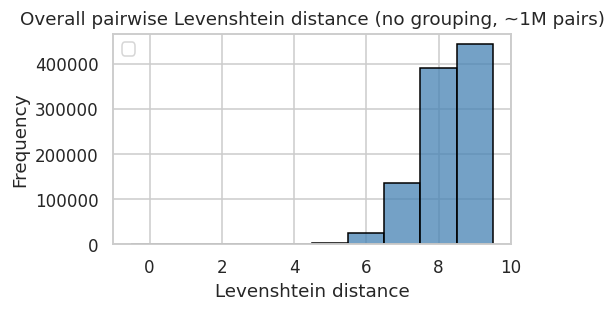

/tmp/ipykernel_353071/3511438111.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


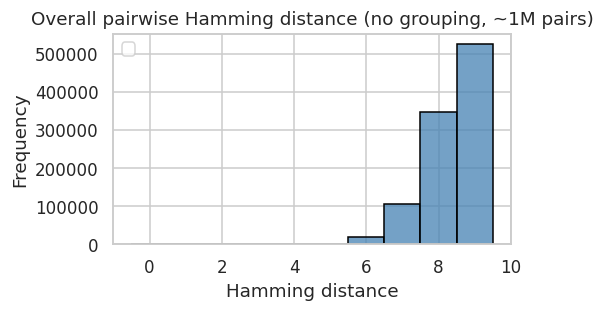

/tmp/ipykernel_353071/3511438111.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


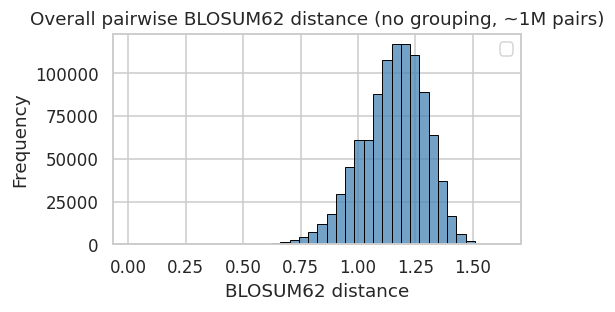

In [127]:
# one standalone figure per metric (integer bins for Levenshtein/Hamming, continuous for BLOSUM62)
bins_by_metric = {
    "Levenshtein": np.arange(-0.5, PEPTIDE_LENGTH + 1.5),
    "Hamming":     np.arange(-0.5, PEPTIDE_LENGTH + 1.5),
    "BLOSUM62":    40,
}

for m in METRICS_DICT:
    fig, ax = plt.subplots(figsize=(5, 3))
    sns.histplot(overall[m], bins=bins_by_metric[m], color="steelblue",
                 edgecolor="black", ax=ax)
    #ax.axvline(overall[m].mean(), color="firebrick", ls="--", lw=1,
    #           label=f"mean = {overall[m].mean():.2f}")
    ax.legend()
    ax.set(title=f"Overall pairwise {m} distance (no grouping, ~1M pairs)", #{len(overall_pairs):,}
           xlabel=f"{m} distance", ylabel="Frequency")
    plt.tight_layout()
    plt.show()

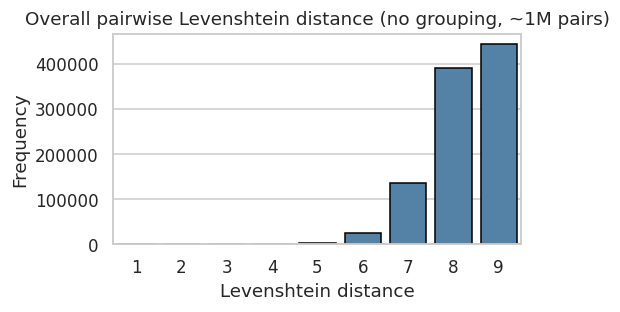

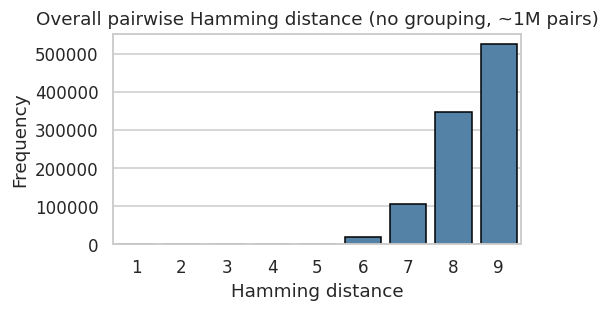

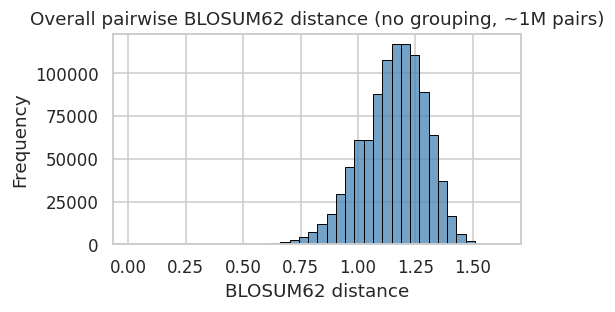

In [ ]:
# one standalone figure per metric: barplots for the integer metrics, histogram for BLOSUM62
INTEGER_METRICS = ["Levenshtein", "Hamming"]

for m in METRICS_DICT:
    fig, ax = plt.subplots(figsize=(5, 3))
    if m in INTEGER_METRICS:
        counts = overall[m].astype(int).value_counts().sort_index()
        sns.barplot(x=counts.index, y=counts.values, color="steelblue",
                    edgecolor="black", ax=ax)
    else:
        sns.histplot(overall[m], bins=40, color="steelblue",
                     edgecolor="black", ax=ax)
    #ax.axvline(overall[m].mean(), color="firebrick", ls="--", lw=1,
    #           label=f"mean = {overall[m].mean():.2f}")
    ax.set(title=f"Overall pairwise {m} distance (~1M pairs)",
           xlabel=f"{m} distance", ylabel="Frequency")
    plt.tight_layout()
    plt.show()


## 4. Similarity by HLA allele

Within-allele = two peptides presented by the **same** HLA allele; between-allele = peptides from **different** alleles. If anchor motifs drive similarity, within-allele distances should be clearly smaller.

In [67]:
allele_groups = build_groups(d, "allele2")
print(len(allele_groups))
print(allele_groups['HLA-A*01:01'][1:5])
print(len(allele_groups['HLA-A*01:01']))

79
['CTDDNALAY' 'LTDDMIAAY' 'KSDGTGTIY' 'ISDYDYYRY']
1039


count      79.000000
mean      561.835443
std       891.510421
min        31.000000
25%        99.000000
50%       284.000000
75%       605.500000
max      6603.000000
dtype: float64


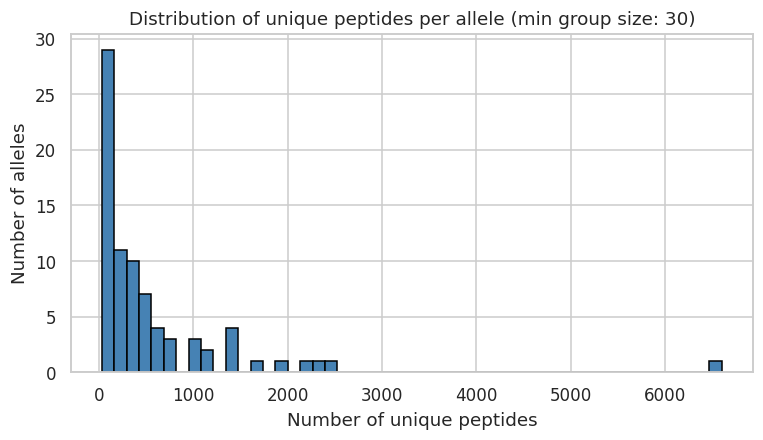

In [68]:
### make a histogram of the number of unique peptides per allele
plt.figure(figsize=(8, 4))
allele_sizes = [len(v) for v in allele_groups.values()]
plt.hist(allele_sizes, bins=50, color="steelblue", edgecolor="black")
plt.title(f"Distribution of unique peptides per allele (min group size: {MIN_GROUP})")
plt.xlabel("Number of unique peptides")
plt.ylabel("Number of alleles")


print(pd.Series(allele_sizes).describe())

In [69]:
print(f"alleles used (>= {MIN_GROUP} peptides): {len(allele_groups)}")

alleles used (>= 30 peptides): 79


One iteration of sampling:

In [70]:
DISTANCE_METRIC = "Hamming"  # or "BLOSUM62"
total_samples = 1000000

wp = sample_within(groups=allele_groups, n=total_samples)
bp = sample_between(groups=allele_groups, n=total_samples)

wp_dists = dists(wp, DISTANCE_METRIC)
bp_dists = dists(bp, DISTANCE_METRIC)

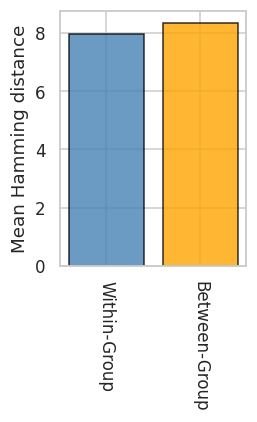

In [71]:
### make a paried bar plot of the within-group and between-group distances
plt.figure(figsize=(2.5, 4))
plt.bar(["Within-Group", "Between-Group"], [wp_dists.mean(), bp_dists.mean()], color=["steelblue", "orange"], alpha=0.8, edgecolor="black")
plt.ylabel("Mean Hamming distance")
plt.xticks(rotation=-90)
plt.tight_layout()
plt.show()

In [72]:
res_allele = compare(wp=wp, bp=bp, label="HLA allele")
res_allele.groupby(["metric", "pair"])["distance"].describe()[["mean", "50%", "std"]]

mean       50%       std
metric      pair                                 
BLOSUM62    between  1.139523  1.152499  0.139033
            within   1.065139  1.078674  0.155016
Hamming     between  8.351740  9.000000  0.782456
            within   7.963213  8.000000  0.949086
Levenshtein between  8.231362  8.000000  0.818929
            within   7.851195  8.000000  0.965312

In [73]:
res_allele

,grouping,metric,pair,distance
0,HLA allele,Levenshtein,within,8.000000
1,HLA allele,Levenshtein,within,8.000000
2,HLA allele,Levenshtein,within,8.000000
3,HLA allele,Levenshtein,within,8.000000
4,HLA allele,Levenshtein,within,9.000000
...,...,...,...,...
5999995,HLA allele,BLOSUM62,between,0.931535
5999996,HLA allele,BLOSUM62,between,0.957874
5999997,HLA allele,BLOSUM62,between,1.359755
5999998,HLA allele,BLOSUM62,between,1.000000


### Sampling n_iter times and then visualizing the results

In [74]:
rows = []
n_iter = 10
DISTANCE_METRIC = "Hamming"  # or "BLOSUM62"
for it in range(n_iter):

    wp = sample_within(groups=allele_groups, n=total_samples)
    bp = sample_between(groups=allele_groups, n=total_samples)

    for pair_lbl, dvals in [("within", dists(wp, DISTANCE_METRIC)), ("between", dists(bp, DISTANCE_METRIC))]:
        rows.append(pd.DataFrame({"iter": it, "pair": pair_lbl, "distance": dvals}))
        
res_iters_Hamming = pd.concat(rows, ignore_index=True)


In [75]:
print(f"res_iters shape: {res_iters_Hamming.shape} | unique iterations: {res_iters_Hamming['iter'].nunique()} | unique pair types: {res_iters_Hamming['pair'].nunique()}")
# e.g. mean distance per iteration and pair type
res_iters_Hamming.groupby(["pair", "iter"])["distance"].mean().unstack("pair")

res_iters shape: (20000000, 3) | unique iterations: 10 | unique pair types: 2


pair,between,within
iter,,
0,8.352053,7.965499
1,8.349952,7.962946
2,8.351432,7.965352
3,8.351908,7.962345
4,8.350320,7.964379
5,8.352432,7.964455
6,8.350954,7.964099
7,8.351981,7.963881
8,8.352457,7.963794


/tmp/ipykernel_353071/1807916512.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=iter_means, x="pair", y="mean_distance", order=order,


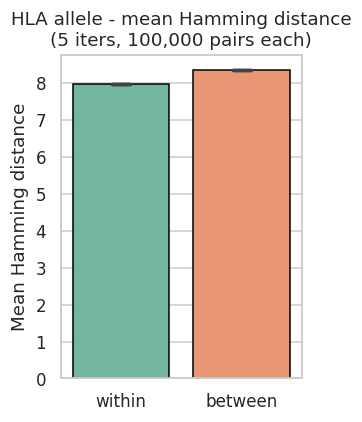

In [106]:
# barplot of mean Hamming distance per pair type, one dot per iteration
iter_means = (res_iters_Hamming.groupby(["pair", "iter"])["distance"]
                       .mean().reset_index(name="mean_distance"))

order = ["within", "between"]
fig, ax = plt.subplots(figsize=(3, 4))
sns.barplot(data=iter_means, x="pair", y="mean_distance", order=order,
            palette="Set2", errorbar="sd", capsize=0.15, ax=ax, edgecolor="black")   # bar = mean over iters, whisker = SD
#sns.stripplot(data=iter_means, x="pair", y="mean_distance", order=order,
#              color="black", size=6, jitter=0.12, ax=ax)          # one dot per iteration

ax.set(title=f"HLA allele - mean Hamming distance\n({n_iter} iters, {total_samples:,} pairs each)",
       xlabel="", ylabel="Mean Hamming distance")
plt.tight_layout(); 
plt.show()

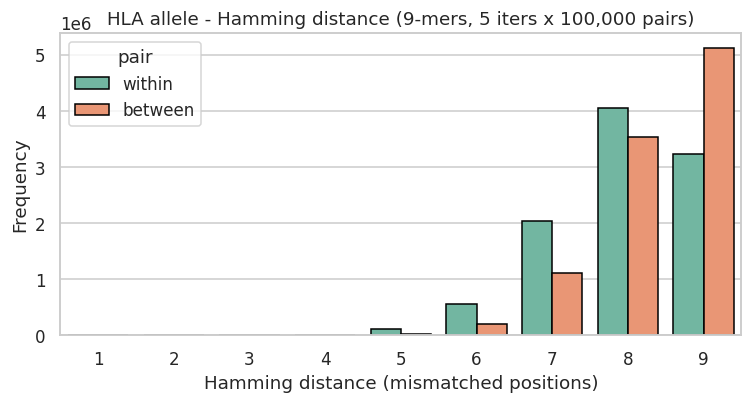

In [108]:
# Hamming: within vs between allele, pooled over all iterations
counts = (res_iters_Hamming
          .groupby(["distance", "pair"]).size()
          .reset_index(name="frequency"))
counts["distance"] = counts["distance"].astype(int)   # integer categories

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=counts, x="distance", y="frequency", hue="pair",
            hue_order=["within", "between"], palette="Set2",
            edgecolor="black", ax=ax)
ax.set(title=f"HLA allele - Hamming distance (9-mers, {n_iter} iters x {total_samples:,} pairs)",
       xlabel="Hamming distance (mismatched positions)", ylabel="Frequency")
plt.tight_layout()
plt.show()


In [78]:
rows = []
n_iter = 5
total_samples = 100000
DISTANCE_METRIC = "BLOSUM62"  # or "Hamming"
for it in range(n_iter):

    wp = sample_within(groups=allele_groups, n=total_samples)
    bp = sample_between(groups=allele_groups, n=total_samples)

    for pair_lbl, dvals in [("within", dists(wp, metric_name=DISTANCE_METRIC)), ("between", dists(bp, metric_name=DISTANCE_METRIC))]:
        rows.append(pd.DataFrame({"iter": it, "pair": pair_lbl, "distance": dvals}))
        
res_iters_BLOSUM62 = pd.concat(rows, ignore_index=True)


/tmp/ipykernel_353071/531519918.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=iter_means, x="pair", y="mean_distance", order=order,


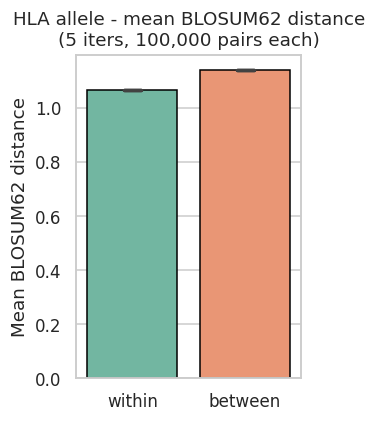

In [ ]:
# barplot of mean BLOSUM62 distance per pair type, one dot per iteration
iter_means = (res_iters_BLOSUM62.groupby(["pair", "iter"])["distance"]
                       .mean().reset_index(name="mean_distance"))

order = ["within", "between"]
fig, ax = plt.subplots(figsize=(3, 4))
sns.barplot(data=iter_means, x="pair", y="mean_distance", order=order,
            palette="Set2", errorbar="sd", capsize=0.15, ax=ax, edgecolor="black")   # bar = mean over iters, whisker = SD
#sns.stripplot(data=iter_means, x="pair", y="mean_distance", order=order,
#              color="black", size=6, jitter=0.12, ax=ax)          # one dot per iteration

ax.set(title=f"HLA allele - mean BLOSUM62 distance\n({n_iter} iters, {total_samples:,} pairs each)",
       xlabel="", ylabel="Mean BLOSUM62 distance")
plt.tight_layout(); 
plt.show()

# BLOSUM62: within vs between allele, pooled over all iterations
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=res_iters_BLOSUM62, x="distance", hue="pair", bins=40, stat="density",
             common_norm=False, palette="Set2", ax=ax, edgecolor="black", alpha=0.7)
ax.set(title=f"HLA allele - BLOSUM62 distance (9-mers, {n_iter} iters x {total_samples:,} pairs)",
       xlabel="BLOSUM62 distance")
plt.tight_layout()
plt.show()

/tmp/ipykernel_353071/1615107344.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=res_iters_BLOSUM62, x="pair", y="distance", palette="Set2", ax=ax)


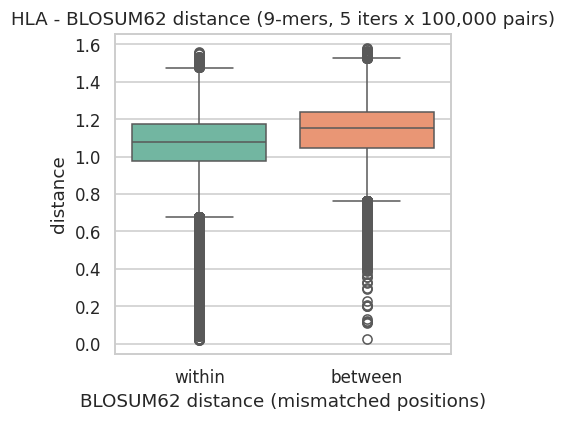

In [80]:
### make a boxplot of the within-group and between-group distances - all data pooled
fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(data=res_iters_BLOSUM62, x="pair", y="distance", palette="Set2", ax=ax)
ax.set(title=f"HLA - {DISTANCE_METRIC} distance (9-mers, {n_iter} iters x {total_samples:,} pairs)",
       xlabel=f"{DISTANCE_METRIC} distance (mismatched positions)")
plt.tight_layout()
plt.show()

## 5. Similarity by source organism

Within-organism = two peptides from the **same** source species; between-organism = peptides from **different** species. If pathogen-level sequence biases drive similarity, within-organism distances should be smaller. (Same sampling/plotting flow as the HLA section above, with the grouping covariate swapped to `species`.)

In [81]:
species_groups = build_groups(d, "species")
print(f"species used (>= {MIN_GROUP} peptides): {len(species_groups)}")
print(list(species_groups)[:5])

species used (>= 30 peptides): 76
['Alphapapillomavirus 7', 'Alphapapillomavirus 9', 'Alphapolyomavirus quintihominis', 'Bacillus anthracis', 'Bacillus cereus']


count      76.000000
mean      263.197368
std       541.392083
min        30.000000
25%        57.000000
50%       115.000000
75%       234.250000
max      4028.000000
dtype: float64


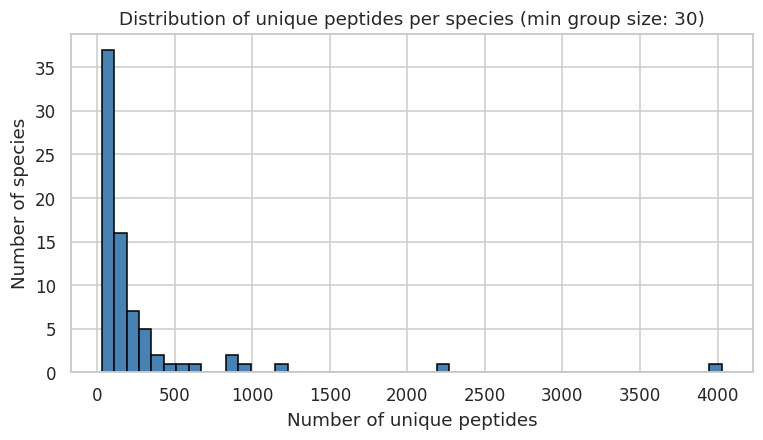

In [82]:
### make a histogram of the number of unique peptides per species
plt.figure(figsize=(8, 4))
species_sizes = [len(v) for v in species_groups.values()]
plt.hist(species_sizes, bins=50, color="steelblue", edgecolor="black")
plt.title(f"Distribution of unique peptides per species (min group size: {MIN_GROUP})")
plt.xlabel("Number of unique peptides")
plt.ylabel("Number of species")


print(pd.Series(species_sizes).describe())

One iteration of sampling:

In [83]:
total_samples = 1000000
wp = sample_within(groups=species_groups, n=total_samples)
bp = sample_between(groups=species_groups, n=total_samples)

wp_dists = dists(wp, "Hamming")
bp_dists = dists(bp, "Hamming")

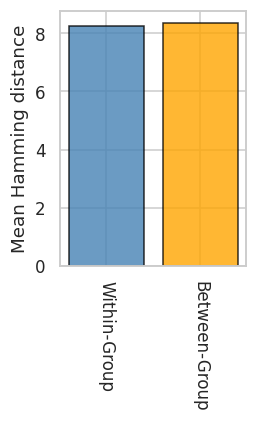

In [84]:
### make a paried bar plot of the within-group and between-group distances
plt.figure(figsize=(2.5, 4))
plt.bar(["Within-Group", "Between-Group"], [wp_dists.mean(), bp_dists.mean()], color=["steelblue", "orange"], alpha=0.8, edgecolor="black")
plt.ylabel("Mean Hamming distance")
plt.xticks(rotation=-90)
plt.tight_layout()
plt.show()

In [85]:
res_species = compare(wp=wp, bp=bp, label="source organism")
res_species.groupby(["metric", "pair"])["distance"].describe()[["mean", "50%", "std"]]

mean       50%       std
metric      pair                                 
BLOSUM62    between  1.152909  1.165479  0.138990
            within   1.130742  1.146342  0.153098
Hamming     between  8.361024  9.000000  0.774503
            within   8.245408  8.000000  0.882414
Levenshtein between  8.234008  8.000000  0.813325
            within   8.095902  8.000000  0.943920

In [86]:
res_species

,grouping,metric,pair,distance
0,source organism,Levenshtein,within,9.000000
1,source organism,Levenshtein,within,9.000000
2,source organism,Levenshtein,within,9.000000
3,source organism,Levenshtein,within,7.000000
4,source organism,Levenshtein,within,7.000000
...,...,...,...,...
5999995,source organism,BLOSUM62,between,1.021148
5999996,source organism,BLOSUM62,between,0.867925
5999997,source organism,BLOSUM62,between,1.129399
5999998,source organism,BLOSUM62,between,1.253320


### Sampling n_iter times and then visualizing the results

In [87]:
rows = []
n_iter = 10
total_samples = 1000000
DISTANCE_METRIC = "Hamming"  # or "BLOSUM62"
for it in range(n_iter):

    wp = sample_within(groups=species_groups, n=total_samples)
    bp = sample_between(groups=species_groups, n=total_samples)

    for pair_lbl, dvals in [("within", dists(wp, DISTANCE_METRIC)), 
                            ("between", dists(bp, DISTANCE_METRIC))]:
        rows.append(pd.DataFrame({"iter": it, "pair": pair_lbl, "distance": dvals}))
        
res_iters_Hamming_species = pd.concat(rows, ignore_index=True)

In [88]:
print(f"res_iters shape: {res_iters_Hamming_species.shape} | unique iterations: {res_iters_Hamming_species['iter'].nunique()} | unique pair types: {res_iters_Hamming_species['pair'].nunique()}")
# e.g. mean distance per iteration and pair type
res_iters_Hamming_species.groupby(["pair", "iter"])["distance"].mean().unstack("pair")

res_iters shape: (20000000, 3) | unique iterations: 10 | unique pair types: 2


pair,between,within
iter,,
0,8.361567,8.245510
1,8.361089,8.244686
2,8.360666,8.246246
3,8.360785,8.245282
4,8.361875,8.242896
5,8.361161,8.244475
6,8.361783,8.244305
7,8.361084,8.245928
8,8.361227,8.245881


/tmp/ipykernel_353071/3573352307.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=iter_means, x="pair", y="mean_distance", order=order,


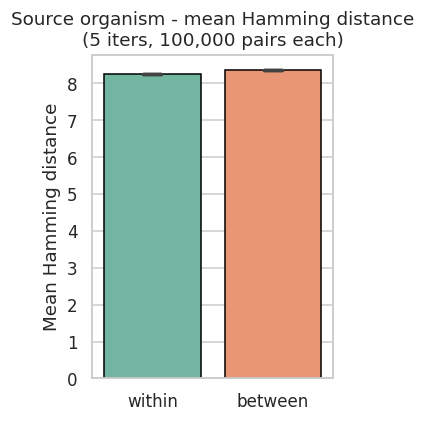

In [113]:
# barplot of mean Hamming distance per pair type, one dot per iteration
iter_means = (res_iters_Hamming_species.groupby(["pair", "iter"])["distance"]
                       .mean().reset_index(name="mean_distance"))

order = ["within", "between"]
fig, ax = plt.subplots(figsize=(3, 4))
sns.barplot(data=iter_means, x="pair", y="mean_distance", order=order,
            palette="Set2", errorbar="sd", capsize=0.15, ax=ax, edgecolor="black")   # bar = mean over iters, whisker = SD
#sns.stripplot(data=iter_means, x="pair", y="mean_distance", order=order,
#              color="black", size=6, jitter=0.12, ax=ax)          # one dot per iteration

ax.set(title=f"Source organism - mean Hamming distance\n({n_iter} iters, {total_samples:,} pairs each)",
       xlabel="", ylabel="Mean Hamming distance")
plt.tight_layout(); 
plt.show()

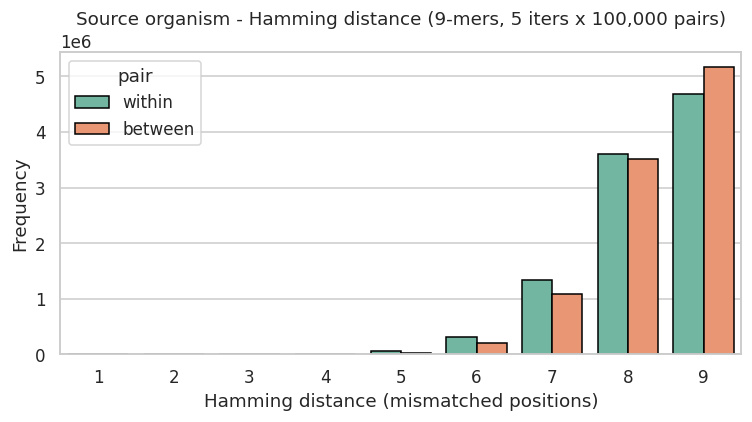

In [112]:
# Hamming: within vs between organism, pooled over all iterations
counts = (res_iters_Hamming_species
          .groupby(["distance", "pair"]).size()
          .reset_index(name="frequency"))
counts["distance"] = counts["distance"].astype(int)   # integer categories


fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=counts, x="distance", y="frequency", hue="pair",
            hue_order=["within", "between"], palette="Set2",
            edgecolor="black", ax=ax)
ax.set(title=f"Source organism - Hamming distance (9-mers, {n_iter} iters x {total_samples:,} pairs)",
       xlabel="Hamming distance (mismatched positions)", ylabel="Frequency")
plt.tight_layout()
plt.show()

In [111]:
counts

,distance,pair,frequency
0,1,between,33
1,1,within,5473
2,2,between,41
3,2,within,3948
4,3,between,113
5,3,within,4371
6,4,between,2024
7,4,within,9358
8,5,between,23863
9,5,within,52244


In [114]:
rows = []
n_iter = 5
total_samples = 100000
DISTANCE_METRIC = "BLOSUM62"  # or "Hamming"
for it in range(n_iter):

    wp = sample_within(groups=species_groups, n=total_samples)
    bp = sample_between(groups=species_groups, n=total_samples)

    for pair_lbl, dvals in [("within", dists(wp, metric_name=DISTANCE_METRIC)), ("between", dists(bp, metric_name=DISTANCE_METRIC))]:
        rows.append(pd.DataFrame({"iter": it, "pair": pair_lbl, "distance": dvals}))
        
res_iters_BLOSUM62_species = pd.concat(rows, ignore_index=True)

/tmp/ipykernel_353071/287123140.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=iter_means, x="pair", y="mean_distance", order=order,


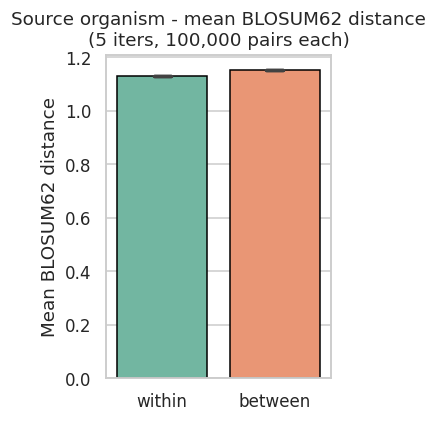

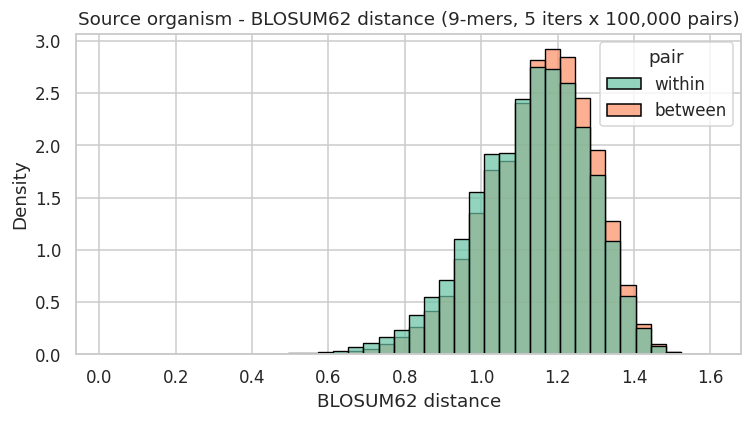

In [115]:
# barplot of mean BLOSUM62 distance per pair type, one dot per iteration
iter_means = (res_iters_BLOSUM62_species.groupby(["pair", "iter"])["distance"]
                       .mean().reset_index(name="mean_distance"))

order = ["within", "between"]
fig, ax = plt.subplots(figsize=(3, 4))
sns.barplot(data=iter_means, x="pair", y="mean_distance", order=order,
            palette="Set2", errorbar="sd", capsize=0.15, ax=ax, edgecolor="black")   # bar = mean over iters, whisker = SD
#sns.stripplot(data=iter_means, x="pair", y="mean_distance", order=order,
#              color="black", size=6, jitter=0.12, ax=ax)          # one dot per iteration

ax.set(title=f"Source organism - mean BLOSUM62 distance\n({n_iter} iters, {total_samples:,} pairs each)",
       xlabel="", ylabel="Mean BLOSUM62 distance")
plt.tight_layout(); 
plt.show()

# BLOSUM62: within vs between organism, pooled over all iterations
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=res_iters_BLOSUM62_species, x="distance", hue="pair", bins=40, stat="density",
             common_norm=False, palette="Set2", ax=ax,
             edgecolor="black", alpha=0.7)
ax.set(title=f"Source organism - BLOSUM62 distance (9-mers, {n_iter} iters x {total_samples:,} pairs)",
       xlabel="BLOSUM62 distance")
plt.tight_layout()
plt.show()

/tmp/ipykernel_353071/2888546953.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=res_iters_BLOSUM62_species, x="pair", y="distance", palette="Set2", ax=ax)


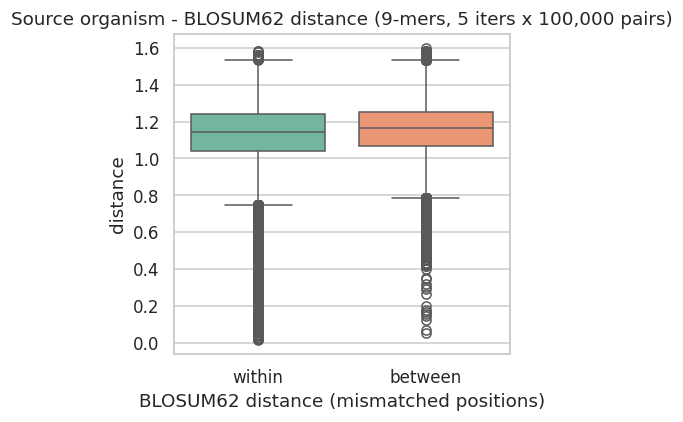

In [93]:
### make a boxplot of the within-group and between-group distances - all data pooled
fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(data=res_iters_BLOSUM62_species, x="pair", y="distance", palette="Set2", ax=ax)
ax.set(title=f"Source organism - {DISTANCE_METRIC} distance (9-mers, {n_iter} iters x {total_samples:,} pairs)",
       xlabel=f"{DISTANCE_METRIC} distance (mismatched positions)")
plt.tight_layout()
plt.show()

## 5b. Similarity by source protein

Grouping key = `source_molecule_iri` (UniProt/NCBI accession — cleaner than the free-text protein name, since the same name maps to several accessions across strains). Expectation: same-protein peptides are overlapping/adjacent windows of one sequence, so this should show a **much larger** within-group effect than organism — and is the main confound behind the organism signal.

In [94]:
protein_groups = build_groups(d, "source_molecule_iri")
print(f"proteins used (>= {MIN_GROUP} peptides): {len(protein_groups)}")
print(list(protein_groups)[:5])

proteins used (>= 30 peptides): 115
['http://www.ncbi.nlm.nih.gov/protein/2110212G', 'http://www.ncbi.nlm.nih.gov/protein/2VDW_H', 'http://www.ncbi.nlm.nih.gov/protein/AAA48028.1', 'http://www.ncbi.nlm.nih.gov/protein/AAA48058.1', 'http://www.ncbi.nlm.nih.gov/protein/AAA48069.1']


count    115.000000
mean      85.565217
std      102.348830
min       30.000000
25%       38.000000
50%       52.000000
75%       83.000000
max      572.000000
dtype: float64


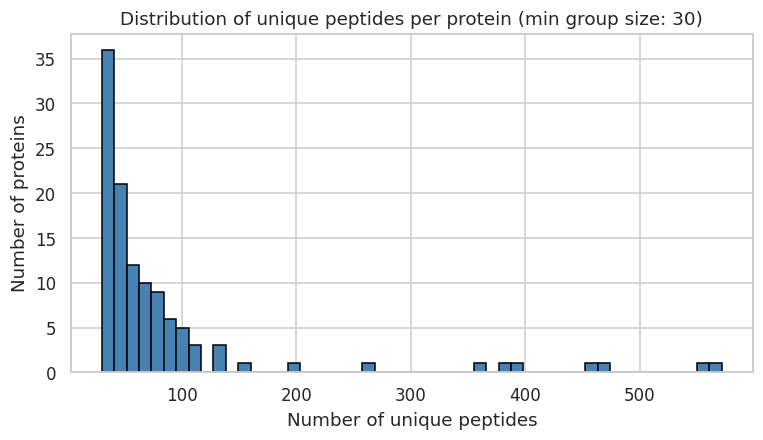

In [95]:
### make a histogram of the number of unique peptides per protein
plt.figure(figsize=(8, 4))
protein_sizes = [len(v) for v in protein_groups.values()]
plt.hist(protein_sizes, bins=50, color="steelblue", edgecolor="black")
plt.title(f"Distribution of unique peptides per protein (min group size: {MIN_GROUP})")
plt.xlabel("Number of unique peptides")
plt.ylabel("Number of proteins")


print(pd.Series(protein_sizes).describe())

One iteration of sampling:

In [96]:
total_samples = 1000000
wp = sample_within(groups=protein_groups, n=total_samples)
bp = sample_between(groups=protein_groups, n=total_samples)

wp_dists = dists(wp, "Hamming")
bp_dists = dists(bp, "Hamming")

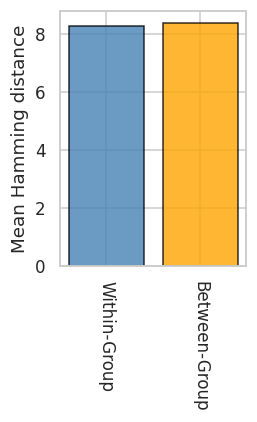

In [97]:
### make a paried bar plot of the within-group and between-group distances
plt.figure(figsize=(2.5, 4))
plt.bar(["Within-Group", "Between-Group"], [wp_dists.mean(), bp_dists.mean()], color=["steelblue", "orange"], alpha=0.8, edgecolor="black")
plt.ylabel("Mean Hamming distance")
plt.xticks(rotation=-90)
plt.tight_layout()
plt.show()

In [98]:
res_protein = compare(wp=wp, bp=bp, label="source protein")
res_protein.groupby(["metric", "pair"])["distance"].describe()[["mean", "50%", "std"]]

mean       50%       std
metric      pair                                 
BLOSUM62    between  1.152139  1.163903  0.138034
            within   1.130469  1.143126  0.146640
Hamming     between  8.388141  9.000000  0.757657
            within   8.279643  8.000000  0.822293
Levenshtein between  8.251808  8.000000  0.803335
            within   8.068407  8.000000  1.012783

In [99]:
res_protein

,grouping,metric,pair,distance
0,source protein,Levenshtein,within,8.000000
1,source protein,Levenshtein,within,4.000000
2,source protein,Levenshtein,within,8.000000
3,source protein,Levenshtein,within,9.000000
4,source protein,Levenshtein,within,8.000000
...,...,...,...,...
5999995,source protein,BLOSUM62,between,1.047140
5999996,source protein,BLOSUM62,between,1.191489
5999997,source protein,BLOSUM62,between,1.190330
5999998,source protein,BLOSUM62,between,1.000000


### Sampling n_iter times and then visualizing the results

In [100]:
rows = []
n_iter = 10
total_samples = 1000000
DISTANCE_METRIC = "Hamming"  # or "BLOSUM62"
for it in range(n_iter):

    wp = sample_within(groups=protein_groups, n=total_samples)
    bp = sample_between(groups=protein_groups, n=total_samples)

    for pair_lbl, dvals in [("within", dists(wp, DISTANCE_METRIC)), ("between", dists(bp, DISTANCE_METRIC))]:
        rows.append(pd.DataFrame({"iter": it, "pair": pair_lbl, "distance": dvals}))
        
res_iters_Hamming_protein = pd.concat(rows, ignore_index=True)

In [101]:
print(f"res_iters shape: {res_iters_Hamming_protein.shape} | unique iterations: {res_iters_Hamming_protein['iter'].nunique()} | unique pair types: {res_iters_Hamming_protein['pair'].nunique()}")
# e.g. mean distance per iteration and pair type
res_iters_Hamming_protein.groupby(["pair", "iter"])["distance"].mean().unstack("pair")

res_iters shape: (20000000, 3) | unique iterations: 10 | unique pair types: 2


pair,between,within
iter,,
0,8.386601,8.278666
1,8.386569,8.278247
2,8.387994,8.279125
3,8.387870,8.280041
4,8.386159,8.278316
5,8.385083,8.279545
6,8.386137,8.279198
7,8.386969,8.280203
8,8.388347,8.279148


/tmp/ipykernel_353071/2024242786.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=iter_means, x="pair", y="mean_distance", order=order,


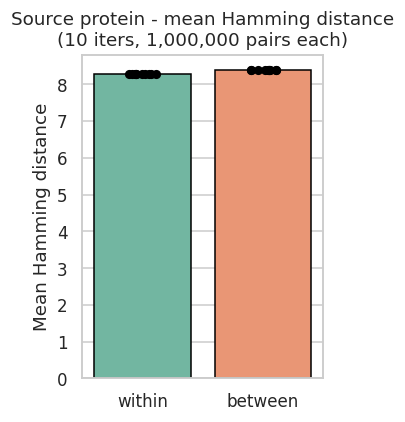

In [102]:
# barplot of mean Hamming distance per pair type, one dot per iteration
iter_means = (res_iters_Hamming_protein.groupby(["pair", "iter"])["distance"]
                       .mean().reset_index(name="mean_distance"))

order = ["within", "between"]
fig, ax = plt.subplots(figsize=(3, 4))
sns.barplot(data=iter_means, x="pair", y="mean_distance", order=order,
            palette="Set2", errorbar="sd", capsize=0.15, ax=ax, edgecolor="black")   # bar = mean over iters, whisker = SD
sns.stripplot(data=iter_means, x="pair", y="mean_distance", order=order,
              color="black", size=6, jitter=0.12, ax=ax)          # one dot per iteration

ax.set(title=f"Source protein - mean Hamming distance\n({n_iter} iters, {total_samples:,} pairs each)",
       xlabel="", ylabel="Mean Hamming distance")
plt.tight_layout(); 
plt.show()

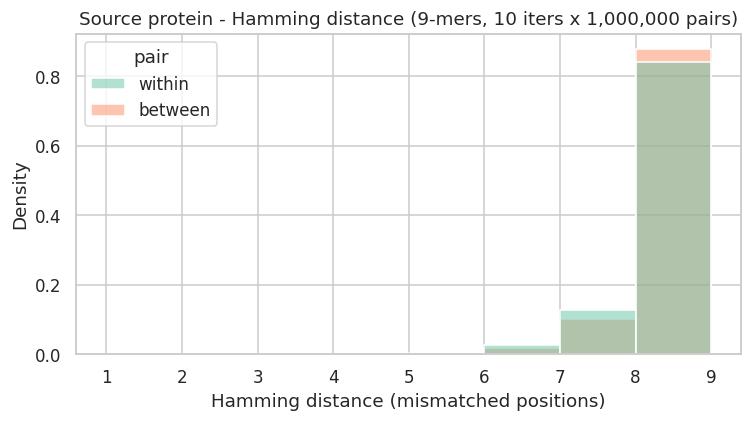

In [103]:
# Hamming: within vs between protein, pooled over all iterations
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=res_iters_Hamming_protein, x="distance", hue="pair", binwidth=1, stat="density",
             common_norm=False, palette="Set2", ax=ax)
ax.set(title=f"Source protein - {DISTANCE_METRIC} distance (9-mers, {n_iter} iters x {total_samples:,} pairs)",
       xlabel=f"{DISTANCE_METRIC} distance (mismatched positions)")
plt.tight_layout()
plt.show()

In [104]:
rows = []
n_iter = 5
total_samples = 100000
DISTANCE_METRIC = "BLOSUM62"  # or "Hamming"
for it in range(n_iter):

    wp = sample_within(groups=protein_groups, n=total_samples)
    bp = sample_between(groups=protein_groups, n=total_samples)

    for pair_lbl, dvals in [("within", dists(wp, metric_name=DISTANCE_METRIC)), ("between", dists(bp, metric_name=DISTANCE_METRIC))]:
        rows.append(pd.DataFrame({"iter": it, "pair": pair_lbl, "distance": dvals}))
        
res_iters_BLOSUM62_protein = pd.concat(rows, ignore_index=True)

/tmp/ipykernel_353071/2683400934.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=iter_means, x="pair", y="mean_distance", order=order,


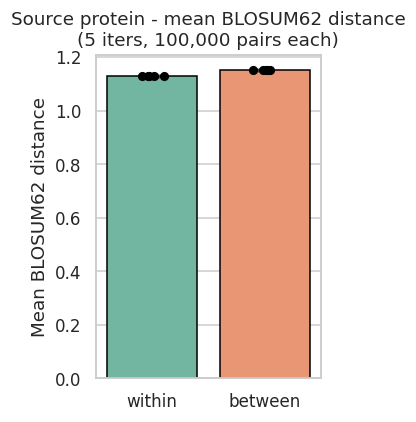

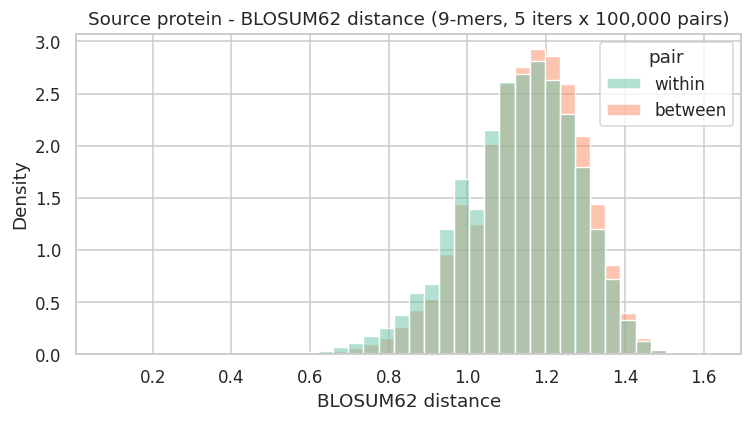

In [105]:
# barplot of mean BLOSUM62 distance per pair type, one dot per iteration
iter_means = (res_iters_BLOSUM62_protein.groupby(["pair", "iter"])["distance"]
                       .mean().reset_index(name="mean_distance"))

order = ["within", "between"]
fig, ax = plt.subplots(figsize=(3, 4))
sns.barplot(data=iter_means, x="pair", y="mean_distance", order=order,
            palette="Set2", errorbar="sd", capsize=0.15, ax=ax, edgecolor="black")   # bar = mean over iters, whisker = SD
sns.stripplot(data=iter_means, x="pair", y="mean_distance", order=order,
              color="black", size=6, jitter=0.12, ax=ax)          # one dot per iteration

ax.set(title=f"Source protein - mean BLOSUM62 distance\n({n_iter} iters, {total_samples:,} pairs each)",
       xlabel="", ylabel="Mean BLOSUM62 distance")
plt.tight_layout(); 
plt.show()

# BLOSUM62: within vs between protein, pooled over all iterations
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=res_iters_BLOSUM62_protein, x="distance", hue="pair", bins=40, stat="density",
             common_norm=False, palette="Set2", ax=ax)
ax.set(title=f"Source protein - BLOSUM62 distance (9-mers, {n_iter} iters x {total_samples:,} pairs)",
       xlabel="BLOSUM62 distance")
plt.tight_layout()
plt.show()

## 7. Notes / next steps

- **Confound to address next:** the organism effect is contaminated by **shared source protein** (many epitopes of one pathogen come from one polyprotein) and by **HLA** (a pathogen's epitopes skew toward common alleles). Next iteration: recompute the organism within-vs-between while holding **allele fixed** and excluding same-protein pairs.
- Extend beyond 9-mers (10/11-mers) using Levenshtein / alignment-based BLOSUM for unequal lengths.
- Consider an allele-vs-allele and organism-vs-organism mean-distance heatmap to see which alleles/pathogens cluster.